In [ ]:
from google.colab import drive
from pathlib import Path
import pandas as pd, numpy as np, pickle, json

drive.mount('/content/drive')
DATA_DIR  = Path("/content/drive/MyDrive/cse440_project")
SPLIT_DIR = DATA_DIR / "splits"
REPR_DIR  = DATA_DIR / "representations"

assert SPLIT_DIR.exists(), "shortcut not added to My Drive — redo step 1"

train = pd.read_parquet(SPLIT_DIR / "train.parquet")
val   = pd.read_parquet(SPLIT_DIR / "val.parquet")
test  = pd.read_parquet(SPLIT_DIR / "test.parquet")
labels = json.load(open(SPLIT_DIR / "label_map.json"))

X_train_seq = np.load(REPR_DIR / "seq_train.npy")
X_val_seq   = np.load(REPR_DIR / "seq_val.npy")
X_test_seq  = np.load(REPR_DIR / "seq_test.npy")
emb_glove   = np.load(REPR_DIR / "emb_glove.npy")
emb_w2v     = np.load(REPR_DIR / "emb_word2vec.npy")
tokenizer   = pickle.load(open(REPR_DIR / "tokenizer.pkl", "rb"))

print(train.shape, val.shape, test.shape, emb_glove.shape)
print(f"checksum tr : {pd.util.hash_pandas_object(train.text_clean).sum()}")

Mounted at /content/drive
(9249, 5) (1633, 5) (7262, 5) (20000, 50)
checksum tr : 13885266476465583340


In [ ]:
import time, json, gc
from scipy import sparse

TEAM_CHECKSUM_TRAIN = 13885266476465583340
DATASET_CHECKSUM    = TEAM_CHECKSUM_TRAIN

my_checksum = int(pd.util.hash_pandas_object(train.text_clean).sum())
assert my_checksum == TEAM_CHECKSUM_TRAIN, (
    f"checksum mismatch: {my_checksum} != {TEAM_CHECKSUM_TRAIN} — "
    "the shared splits changed, do not train")

X_train_tfidf = sparse.load_npz(REPR_DIR / "tfidf_train.npz")
X_val_tfidf   = sparse.load_npz(REPR_DIR / "tfidf_val.npz")
X_test_tfidf  = sparse.load_npz(REPR_DIR / "tfidf_test.npz")
meta = json.load(open(REPR_DIR / "repr_meta.json"))

CLASS_NAMES = labels["classes"]
SUPERCLASS  = labels["superclass"]
NUM_CLASSES = labels["num_classes"]

y_train = train["label"].to_numpy()
y_val   = val["label"].to_numpy()
y_test  = test["label"].to_numpy()

SEED      = 42
MAX_LEN   = meta["max_len"]
MAX_VOCAB = meta["max_vocab"]

RESULT_DIR = DATA_DIR / "results" / "hasib"
FIG_DIR    = DATA_DIR / "figures" / "hasib"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_OUT = Path("/content/hasib_outputs")
LOCAL_OUT.mkdir(parents=True, exist_ok=True)

print("checksum verified")
print(f"tfidf shapes : {X_train_tfidf.shape} {X_val_tfidf.shape} {X_test_tfidf.shape}")
print(f"seq shapes   : {X_train_seq.shape} {X_val_seq.shape} {X_test_seq.shape}")
print(f"emb shapes   : glove {emb_glove.shape}  w2v {emb_w2v.shape}")
print(f"coverage     : w2v {meta['coverage_word2vec']:.1%}  glove {meta['coverage_glove']:.1%}")

checksum verified
tfidf shapes : (9249, 20000) (1633, 20000) (7262, 20000)
seq shapes   : (9249, 250) (1633, 250) (7262, 250)
emb shapes   : glove (20000, 50)  w2v (20000, 50)
coverage     : w2v 100.0%  glove 87.3%


In [ ]:
for name, df, tf_m, sq in [("train", train, X_train_tfidf, X_train_seq),
                           ("val",   val,   X_val_tfidf,   X_val_seq),
                           ("test",  test,  X_test_tfidf,  X_test_seq)]:
    assert tf_m.shape[0] == len(df), f"{name}: tfidf rows != parquet rows"
    assert sq.shape[0]  == len(df),  f"{name}: sequence rows != parquet rows"
    assert sq.shape[1]  == MAX_LEN,  f"{name}: sequence length != MAX_LEN"

assert emb_glove.shape == emb_w2v.shape
assert int(X_train_seq.max()) < emb_glove.shape[0], "token id outside embedding matrix"
assert set(np.unique(y_train)) == set(range(NUM_CLASSES))

print(f"alignment ok — {NUM_CLASSES} classes, vocab {emb_glove.shape[0]:,}, "
      f"dim {emb_glove.shape[1]}, max_len {MAX_LEN}")
print(f"padding rows : row 0 all-zero = {bool((emb_glove[0] == 0).all())}")

alignment ok — 20 classes, vocab 20,000, dim 50, max_len 250
padding rows : row 0 all-zero = True


In [ ]:
import shutil

def _writable(path):
    try:
        path.mkdir(parents=True, exist_ok=True)
        probe = path / ".write_test"
        probe.write_text("ok")
        probe.unlink()
        return True
    except Exception as exc:
        print(f"drive not writable at {path} -> {type(exc).__name__}: {exc}")
        return False


DRIVE_FIG_OK = _writable(FIG_DIR)
DRIVE_RES_OK = _writable(RESULT_DIR)


def save_artifact(local_path, drive_dir, drive_ok):
    print(f"saved {local_path}")
    if drive_ok:
        try:
            shutil.copy(local_path, drive_dir / local_path.name)
            print(f"copied to {drive_dir / local_path.name}")
        except Exception as exc:
            print(f"drive copy failed -> {type(exc).__name__}: {exc}")
    else:
        print("drive copy skipped — download from the Files pane instead")


def save_fig(fig, name):
    local = LOCAL_OUT / name
    fig.savefig(local, dpi=150, bbox_inches="tight")
    save_artifact(local, FIG_DIR, DRIVE_FIG_OK)
    return local


print(f"local outputs : {LOCAL_OUT}")
print(f"figures -> drive : {DRIVE_FIG_OK}")
print(f"results -> drive : {DRIVE_RES_OK}")

local outputs : /content/hasib_outputs
figures -> drive : True
results -> drive : True


In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print(f"tensorflow : {tf.__version__}")
print(f"keras      : {keras.__version__}")
print(f"gpu        : {gpus if gpus else 'NONE — switch runtime to T4 before section 4'}")

tensorflow : 2.20.0
keras      : 3.13.2
gpu        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


=== CONTRIB START ===

## Shared scoring contract

Every model in this project is scored by `utils/evaluation.py`, the module Fabiha
published. Printing the contract puts the guarantee in the output instead of leaving it
assumed. Macro-F1 is always computed with `average="macro"` over all 20 labels and
`zero_division=0`, so the number means the same thing in all 36 runs.

The assert on `RUN_COLUMNS` blocks training if the module on Drive is the older
23-column version.

In [ ]:
import sys, importlib

sys.path.insert(0, str(DATA_DIR))
import utils.evaluation as ev
importlib.reload(ev)

ev.print_contract()
assert len(ev.RUN_COLUMNS) == 26, (
    f"got a {len(ev.RUN_COLUMNS)}-column schema — Fabiha needs to re-run §1c of "
    "04_lstm_fabiha.ipynb so contract v1.1 is published to Drive")

RUNS = []
RUNS_CSV = LOCAL_OUT / "runs_hasib.csv"
if RUNS_CSV.exists():
    RUNS_CSV.unlink()


def log_run(model, tier, config, embedding, hyperparams, result, seconds,
            notes="required", units=np.nan, dropout=np.nan, trainable_emb=np.nan,
            batch_size=np.nan, learning_rate=np.nan, epochs_run=np.nan,
            best_epoch=np.nan, n_params=np.nan, val_loss=np.nan):
    record = {
        "run_id": f"{model}_{config}",
        "owner": "hasib",
        "notebook": "03_rnn_hasib.ipynb",
        "tier": tier,
        "model": model,
        "config": config,
        "embedding": embedding,
        "units": units,
        "dropout": dropout,
        "trainable_emb": trainable_emb,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "epochs_run": epochs_run,
        "best_epoch": best_epoch,
        "n_params": n_params,
        "hyperparams": json.dumps(hyperparams, sort_keys=True, default=str),
        "val_loss": val_loss,
        "val_accuracy": round(result["accuracy"], 4),
        "val_macro_f1": round(result["macro_f1"], 4),
        "test_accuracy": np.nan,
        "test_macro_f1": np.nan,
        "test_weighted_f1": np.nan,
        "train_time_s": round(seconds, 2),
        "dataset_checksum": DATASET_CHECKSUM,
        "notes": notes,
    }
    ev.log_run(RUNS_CSV, record, echo=False)
    RUNS.append(record)
    print(f"  -> val acc {record['val_accuracy']:.4f} | "
          f"macro-F1 {record['val_macro_f1']:.4f} | "
          f"weighted-F1 {result['weighted_f1']:.4f} | "
          f"{record['train_time_s']:.2f}s")
    return record


def score_val(y_pred, label):
    return ev.evaluate_model(y_val, y_pred, CLASS_NAMES, SUPERCLASS,
                             model_name=label, split="val", verbose=False)


print(f"\nrun logger ready — writing {RUNS_CSV}")

utils.evaluation — scoring contract v1.1
  1. accuracy
  2. macro_f1
  3. weighted_f1
  4. classification_report
  5. confusion_matrix_row_normalised
  6. within_vs_cross_family_error_split

run schema : 26 columns
tiers      : classical, recurrent, transformer
note kinds : required, ablation

run logger ready — writing /content/hasib_outputs/runs_hasib.csv


## Section 8 - Machine Learning Models

Three classical models on the shared TF-IDF matrix: Logistic Regression, Multinomial
Naive Bayes and Random Forest. Three configurations each, nine required runs.

| Model | Varied | Values |
| --- | --- | --- |
| Logistic Regression | inverse regularisation `C` | 1.0, 5.0, 10.0 |
| Multinomial Naive Bayes | smoothing `alpha` | 1.0, 0.1, 0.01 |
| Random Forest | trees, features, leaf size | 300/sqrt/1, 600/sqrt/2, 300/0.02/1 |

Each model varies the parameter that controls its own capacity. For Logistic Regression
and Naive Bayes that is a single regularisation term. For Random Forest it is the size
and diversity of the ensemble.

The same grid `SEQ_GRID` below is used by all six recurrent models in the project. It is
defined here and copied verbatim into the other two notebooks.

In [ ]:
CLASSICAL_GRID = {
    "LogisticRegression": [
        ("LR-C1", {"C": 1.0}),
        ("LR-C2", {"C": 5.0}),
        ("LR-C3", {"C": 10.0}),
    ],
    "MultinomialNB": [
        ("NB-C1", {"alpha": 1.0}),
        ("NB-C2", {"alpha": 0.1}),
        ("NB-C3", {"alpha": 0.01}),
    ],
    "RandomForest": [
        ("RF-C1", {"n_estimators": 300, "max_features": "sqrt", "min_samples_leaf": 1}),
        ("RF-C2", {"n_estimators": 600, "max_features": "sqrt", "min_samples_leaf": 2}),
        ("RF-C3", {"n_estimators": 300, "max_features": 0.02,  "min_samples_leaf": 1}),
    ],
}

SEQ_GRID = [
    ("S1", {"embedding": "glove",    "trainable": False, "units": 64,
            "dropout": 0.3, "lr": 1e-3, "batch_size": 64}),
    ("S2", {"embedding": "word2vec", "trainable": False, "units": 64,
            "dropout": 0.3, "lr": 1e-3, "batch_size": 64}),
    ("S3", {"embedding": "word2vec", "trainable": True,  "units": 128,
            "dropout": 0.5, "lr": 1e-3, "batch_size": 64}),
]

EMBEDDINGS = {"glove": emb_glove, "word2vec": emb_w2v}
EPOCHS     = 30
PATIENCE   = 5
CLIPNORM   = 1.0
LR         = 1e-3
BATCH_SIZE = 64

assert all(c["lr"] == LR and c["batch_size"] == BATCH_SIZE for _, c in SEQ_GRID), \
    "SEQ_GRID disagrees with the shared lr / batch_size constants"

print(f"classical runs planned : {sum(len(v) for v in CLASSICAL_GRID.values())}")
print(f"sequence runs planned  : {2 * len(SEQ_GRID)}")
print(f"epoch cap              : {EPOCHS}  (team-standardised; was 20 before the re-run)")
print(f"early stopping         : val_accuracy, patience {PATIENCE}, restore best weights")

classical runs planned : 9
sequence runs planned  : 6
epoch cap              : 30  (team-standardised; was 20 before the re-run)
early stopping         : val_accuracy, patience 5, restore best weights


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


def make_classical(name, params):
    if name == "LogisticRegression":
        return LogisticRegression(max_iter=2000, random_state=SEED, **params)
    if name == "MultinomialNB":
        return MultinomialNB(**params)
    if name == "RandomForest":
        return RandomForestClassifier(random_state=SEED, n_jobs=-1, **params)
    raise ValueError(name)

print("classical factory ready")

classical factory ready


In [ ]:
best_classical = {}

for name, configs in CLASSICAL_GRID.items():
    print(f"\n=== {name} ===")
    for config_id, params in configs:
        print(f"{config_id}: {params}")
        t0 = time.time()
        clf = make_classical(name, params)
        clf.fit(X_train_tfidf, y_train)
        elapsed = time.time() - t0
        res = score_val(clf.predict(X_val_tfidf), f"{name} ({config_id})")
        row = log_run(name, "classical", config_id, "tfidf_clean", params, res, elapsed,
                      notes="required")

        prev = best_classical.get(name)
        if prev is None or res["macro_f1"] > prev["metrics"]["macro_f1"]:
            best_classical[name] = {"estimator": clf, "config": config_id,
                                    "hyperparams": params, "metrics": res,
                                    "row": row, "run_id": row["run_id"]}
        else:
            del clf
            gc.collect()

print("\nbest classical config per model (by val macro-F1):")
for name, b in best_classical.items():
    print(f"  {name:20s} {b['config']:7s} macro-F1 {b['metrics']['macro_f1']:.4f}")


=== LogisticRegression ===
LR-C1: {'C': 1.0}
  -> val acc 0.7385 | macro-F1 0.7241 | weighted-F1 0.7335 | 10.38s
LR-C2: {'C': 5.0}
  -> val acc 0.7477 | macro-F1 0.7377 | weighted-F1 0.7458 | 12.11s
LR-C3: {'C': 10.0}
  -> val acc 0.7446 | macro-F1 0.7353 | weighted-F1 0.7430 | 11.03s

=== MultinomialNB ===
NB-C1: {'alpha': 1.0}
  -> val acc 0.7110 | macro-F1 0.6887 | weighted-F1 0.7037 | 0.03s
NB-C2: {'alpha': 0.1}
  -> val acc 0.7508 | macro-F1 0.7348 | weighted-F1 0.7446 | 0.02s
NB-C3: {'alpha': 0.01}
  -> val acc 0.7404 | macro-F1 0.7317 | weighted-F1 0.7381 | 0.03s

=== RandomForest ===
RF-C1: {'n_estimators': 300, 'max_features': 'sqrt', 'min_samples_leaf': 1}
  -> val acc 0.6632 | macro-F1 0.6459 | weighted-F1 0.6569 | 63.23s
RF-C2: {'n_estimators': 600, 'max_features': 'sqrt', 'min_samples_leaf': 2}
  -> val acc 0.6767 | macro-F1 0.6593 | weighted-F1 0.6697 | 47.06s
RF-C3: {'n_estimators': 300, 'max_features': 0.02, 'min_samples_leaf': 1}
  -> val acc 0.6412 | macro-F1 0.6238 

### 8.4 Preprocessing ablation

Section 3.4 of the brief asks for a justified comparison of preprocessing strategies.
Phase 0 chose `text_clean` on vocabulary statistics alone. This measures whether that
choice was right.

The best configuration of each classical model is re-fitted on a TF-IDF matrix built
from `text_light`, which keeps stopwords and inflections. Everything else is held fixed.
Three extra runs, not part of the required thirty.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_light = TfidfVectorizer(max_features=MAX_VOCAB, ngram_range=(1, 2),
                              min_df=3, max_df=0.85, sublinear_tf=True)

Xtr_light = tfidf_light.fit_transform(train["text_light"])
Xva_light = tfidf_light.transform(val["text_light"])

print(f"light tfidf train : {Xtr_light.shape}")
print(f"clean tfidf train : {X_train_tfidf.shape}")

try:
    tfidf_clean = pickle.load(open(REPR_DIR / "tfidf_vectorizer.pkl", "rb"))
    shared = set(tfidf_light.get_feature_names_out()) & set(tfidf_clean.get_feature_names_out())
    print(f"shared features   : {len(shared):,}")
except Exception as exc:
    print(f"could not unpickle the Phase 1 vectoriser ({type(exc).__name__}); "
          "shape comparison above is sufficient")

light tfidf train : (9249, 20000)
clean tfidf train : (9249, 20000)
shared features   : 6,417


In [ ]:
for name, b in best_classical.items():
    print(f"\n=== {name} on text_light ({b['config']} hyperparams) ===")
    t0 = time.time()
    clf = make_classical(name, b["hyperparams"])
    clf.fit(Xtr_light, y_train)
    elapsed = time.time() - t0
    res = score_val(clf.predict(Xva_light), f"{name} ({b['config']}-light)")
    log_run(name, "classical", b["config"] + "-light", "tfidf_light",
            b["hyperparams"], res, elapsed,
            notes="ablation preprocessing: text_light instead of text_clean")
    del clf
    gc.collect()


=== LogisticRegression on text_light (LR-C2 hyperparams) ===
  -> val acc 0.7312 | macro-F1 0.7218 | weighted-F1 0.7292 | 15.94s

=== MultinomialNB on text_light (NB-C2 hyperparams) ===
  -> val acc 0.7336 | macro-F1 0.7179 | weighted-F1 0.7276 | 0.03s

=== RandomForest on text_light (RF-C2 hyperparams) ===
  -> val acc 0.6699 | macro-F1 0.6518 | weighted-F1 0.6623 | 82.74s


In [ ]:
ablation = pd.read_csv(RUNS_CSV)
ablation = ablation[ablation.tier == "classical"]

pivot = (ablation.pivot_table(index="model", columns="embedding",
                              values="val_macro_f1", aggfunc="max")
                 .reindex(columns=["tfidf_clean", "tfidf_light"]))
pivot["delta (clean - light)"] = (pivot["tfidf_clean"] - pivot["tfidf_light"]).round(4)
print(pivot.round(4).to_string())

embedding           tfidf_clean  tfidf_light  delta (clean - light)
model                                                              
LogisticRegression       0.7377       0.7218                 0.0159
MultinomialNB            0.7348       0.7179                 0.0169
RandomForest             0.6593       0.6518                 0.0075


The clean strategy wins on all three models: Logistic Regression +0.0159, Naive Bayes
+0.0169, Random Forest +0.0075 validation macro-F1.

The mechanism is the 20,000-feature cap. The light vocabulary spends slots on function
words and inflected variants, so under a fixed cap it represents fewer distinct topical
concepts. Phase 0 measured this indirectly through vocabulary statistics, 66,111 terms
under light against 54,253 under full. This confirms it on model performance.

The margins are small, so the honest reading is that the preprocessing choice matters
less than the vocabulary cap it interacts with.

## Sections 9.1 and 9.2 - SimpleRNN and Bidirectional SimpleRNN

The SimpleRNN applies one recurrent transformation per timestep with no gating. It is
the baseline the gated architectures are measured against.

`mask_zero=True` matters here. Documents are padded to 250 tokens but most are shorter,
so without masking the cell keeps updating its hidden state on zero vectors after the
document ends. `recurrent_dropout` stays at 0.0 because any non-zero value disables the
cuDNN kernel.

Both models use the frozen S1, S2, S3 grid, so the only difference between them is the
`Bidirectional` wrapper.

In [ ]:
def build_sequence_model(arch, cfg):
    keras.utils.set_random_seed(SEED)
    matrix = EMBEDDINGS[cfg["embedding"]]
    vocab_size, dim = matrix.shape

    inputs = keras.Input(shape=(MAX_LEN,), dtype="int32")
    x = keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=dim,
        embeddings_initializer=keras.initializers.Constant(matrix),
        trainable=cfg["trainable"],
        mask_zero=True,
        name="embedding",
    )(inputs)

    if arch == "SimpleRNN":
        x = keras.layers.SimpleRNN(cfg["units"], dropout=cfg["dropout"],
                                   name="rnn")(x)
    elif arch == "BiSimpleRNN":
        x = keras.layers.Bidirectional(
            keras.layers.SimpleRNN(cfg["units"], dropout=cfg["dropout"]),
            name="bi_rnn")(x)
    else:
        raise ValueError(arch)

    x = keras.layers.Dropout(cfg["dropout"])(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=f"{arch}_{cfg['embedding']}")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg["lr"], clipnorm=CLIPNORM),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


demo = build_sequence_model("BiSimpleRNN", SEQ_GRID[0][1])
demo.summary()
del demo
keras.backend.clear_session()

Model: "BiSimpleRNN_glove"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 50)   │  1,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 250)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_rnn              │ (None, 128)       │     14,720 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bi_rnn[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20)        │      2,580 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,017,300 (3.88 MB)

 Trainable params: 17,300 (67.58 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [ ]:
def train_sequence(arch, config_id, cfg):
    keras.backend.clear_session()
    model = build_sequence_model(arch, cfg)

    stopper = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", mode="max",
        patience=PATIENCE, restore_best_weights=True, verbose=1)

    t0 = time.time()
    history = model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=EPOCHS,
        batch_size=cfg["batch_size"],
        callbacks=[stopper],
        verbose=2,
    )
    elapsed = time.time() - t0

    val_probs = model.predict(X_val_seq, batch_size=256, verbose=0)
    res = score_val(val_probs, f"{arch} ({config_id})")

    epochs_run = len(history.history["loss"])
    best_epoch = int(np.argmax(history.history["val_accuracy"])) + 1
    if epochs_run == EPOCHS and best_epoch > EPOCHS - PATIENCE:
        print(f"  note: hit the {EPOCHS}-epoch cap with the best epoch at {best_epoch} — "
              "early stopping never fired, so this run was still improving when it stopped")

    row = log_run(arch, "recurrent", config_id, cfg["embedding"], cfg, res, elapsed,
                  notes="required",
                  units=cfg["units"], dropout=cfg["dropout"],
                  trainable_emb=cfg["trainable"],
                  batch_size=cfg["batch_size"], learning_rate=cfg["lr"],
                  epochs_run=epochs_run, best_epoch=best_epoch,
                  n_params=int(model.count_params()),
                  val_loss=float(min(history.history["val_loss"])))
    return model, history, res, row


best_sequence = {}
histories = {}

for arch in ["SimpleRNN", "BiSimpleRNN"]:
    for config_id, cfg in SEQ_GRID:
        print(f"\n=== {arch} | {config_id} | {cfg} ===")
        model, history, res, row = train_sequence(arch, config_id, cfg)
        histories[(arch, config_id)] = history.history

        prev = best_sequence.get(arch)
        if prev is None or res["macro_f1"] > prev["metrics"]["macro_f1"]:
            best_sequence[arch] = {"model": model, "config": config_id,
                                   "cfg": cfg, "metrics": res, "row": row,
                                   "run_id": row["run_id"]}
        else:
            del model
            gc.collect()

print("\nbest sequence config per architecture (by val macro-F1):")
for arch, b in best_sequence.items():
    print(f"  {arch:14s} {b['config']}  ({b['cfg']['embedding']}) "
          f"macro-F1 {b['metrics']['macro_f1']:.4f}")


=== SimpleRNN | S1 | {'embedding': 'glove', 'trainable': False, 'units': 64, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64} ===
Epoch 1/30
145/145 - 12s - 85ms/step - accuracy: 0.0735 - loss: 3.1265 - val_accuracy: 0.1500 - val_loss: 2.6181
Epoch 2/30
145/145 - 3s - 19ms/step - accuracy: 0.1516 - loss: 2.6689 - val_accuracy: 0.1892 - val_loss: 2.4160
Epoch 3/30
145/145 - 5s - 36ms/step - accuracy: 0.1801 - loss: 2.5258 - val_accuracy: 0.2296 - val_loss: 2.3469
Epoch 4/30
145/145 - 3s - 20ms/step - accuracy: 0.1981 - loss: 2.4468 - val_accuracy: 0.2480 - val_loss: 2.2691
Epoch 5/30
145/145 - 3s - 22ms/step - accuracy: 0.2242 - loss: 2.3601 - val_accuracy: 0.2866 - val_loss: 2.1527
Epoch 6/30
145/145 - 3s - 19ms/step - accuracy: 0.2447 - loss: 2.3034 - val_accuracy: 0.2743 - val_loss: 2.1286
Epoch 7/30
145/145 - 3s - 19ms/step - accuracy: 0.2491 - loss: 2.2813 - val_accuracy: 0.2737 - val_loss: 2.1766
Epoch 8/30
145/145 - 3s - 20ms/step - accuracy: 0.2569 - loss: 2.2485 - val_accuracy: 

  -> val acc 0.4317 | macro-F1 0.3744 | weighted-F1 0.3882 | 88.31s

=== BiSimpleRNN | S1 | {'embedding': 'glove', 'trainable': False, 'units': 64, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64} ===
Epoch 1/30
145/145 - 22s - 152ms/step - accuracy: 0.0947 - loss: 3.0253 - val_accuracy: 0.1837 - val_loss: 2.4469
Epoch 2/30
145/145 - 5s - 34ms/step - accuracy: 0.1829 - loss: 2.5182 - val_accuracy: 0.2352 - val_loss: 2.2833
Epoch 3/30
145/145 - 5s - 35ms/step - accuracy: 0.2266 - loss: 2.3474 - val_accuracy: 0.2897 - val_loss: 2.1310
Epoch 4/30
145/145 - 10s - 70ms/step - accuracy: 0.2534 - loss: 2.2395 - val_accuracy: 0.2805 - val_loss: 2.1321
Epoch 5/30
145/145 - 5s - 36ms/step - accuracy: 0.2890 - loss: 2.1531 - val_accuracy: 0.3429 - val_loss: 1.9884
Epoch 6/30
145/145 - 5s - 33ms/step - accuracy: 0.3081 - loss: 2.0897 - val_accuracy: 0.3484 - val_loss: 1.9548
Epoch 7/30
145/145 - 5s - 34ms/step - accuracy: 0.3196 - loss: 2.0642 - val_accuracy: 0.3564 - val_loss: 1.9163
Epoch 8/30
145

  -> val acc 0.4207 | macro-F1 0.3880 | weighted-F1 0.3990 | 132.55s

=== BiSimpleRNN | S2 | {'embedding': 'word2vec', 'trainable': False, 'units': 64, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64} ===
Epoch 1/30
145/145 - 15s - 105ms/step - accuracy: 0.0990 - loss: 3.0590 - val_accuracy: 0.2058 - val_loss: 2.4194
Epoch 2/30
145/145 - 5s - 35ms/step - accuracy: 0.1939 - loss: 2.5060 - val_accuracy: 0.3068 - val_loss: 2.1198
Epoch 3/30
145/145 - 5s - 34ms/step - accuracy: 0.2458 - loss: 2.2872 - val_accuracy: 0.3264 - val_loss: 2.0085
Epoch 4/30
145/145 - 5s - 33ms/step - accuracy: 0.2786 - loss: 2.1753 - val_accuracy: 0.3576 - val_loss: 1.9152
Epoch 5/30
145/145 - 5s - 36ms/step - accuracy: 0.3039 - loss: 2.0846 - val_accuracy: 0.3833 - val_loss: 1.8648
Epoch 6/30
145/145 - 5s - 33ms/step - accuracy: 0.3089 - loss: 2.0604 - val_accuracy: 0.3993 - val_loss: 1.7898
Epoch 7/30
145/145 - 5s - 33ms/step - accuracy: 0.3267 - loss: 2.0202 - val_accuracy: 0.3919 - val_loss: 1.8124
Epoch 8/30


### Learning curves

The line to watch is whether validation accuracy is still climbing at the final epoch.
That would mean the 30-epoch cap cut the run off rather than early stopping halting it.

This is why the group standardised on 30. The first version of this notebook used 20 and
four runs hit that ceiling while still improving.

saved /content/hasib_outputs/learning_curves_rnn.png
copied to /content/drive/MyDrive/cse440_project/figures/hasib/learning_curves_rnn.png


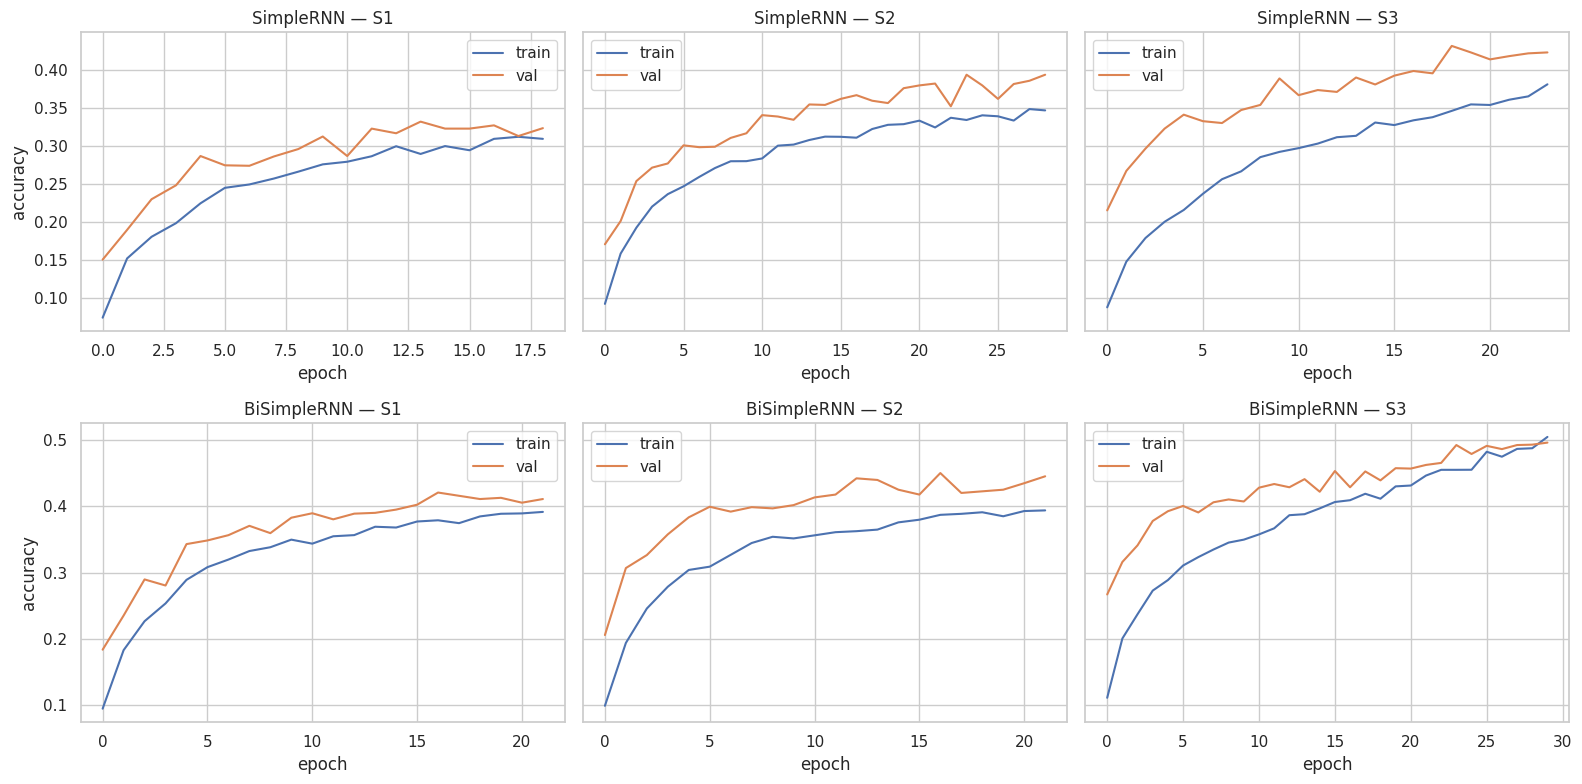

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey="row")

for i, arch in enumerate(["SimpleRNN", "BiSimpleRNN"]):
    for j, (config_id, _) in enumerate(SEQ_GRID):
        h = histories[(arch, config_id)]
        ax = axes[i, j]
        ax.plot(h["accuracy"], label="train")
        ax.plot(h["val_accuracy"], label="val")
        ax.set_title(f"{arch} — {config_id}")
        ax.set_xlabel("epoch")
        if j == 0:
            ax.set_ylabel("accuracy")
        ax.legend()

plt.tight_layout()
save_fig(fig, "learning_curves_rnn.png")
plt.show()

### The embedding contrast, isolated

S1 and S2 differ only in the embedding matrix. Units, dropout and the frozen flag are
identical, so the difference is attributable to the embedding source alone.

GloVe covers 87.32% of the vocabulary and Word2Vec covers 99.995%. Every GloVe miss is a
zero row, which the model reads as a word with no meaning.

In [ ]:
seq_runs = pd.read_csv(RUNS_CSV)
seq_runs = seq_runs[seq_runs.tier == "recurrent"]

contrast = (seq_runs[seq_runs.config.isin(["S1", "S2"])]
            .pivot_table(index="model", columns="embedding",
                         values="val_macro_f1"))
contrast["delta (w2v - glove)"] = (contrast["word2vec"] - contrast["glove"]).round(4)
print("frozen 64-unit models, embedding matrix swapped:")
print(contrast.round(4).to_string())

zero_glove = int((emb_glove.sum(axis=1) == 0).sum())
zero_w2v   = int((emb_w2v.sum(axis=1) == 0).sum())
print(f"\nzero rows — glove {zero_glove:,} / {emb_glove.shape[0]:,}"
      f"   word2vec {zero_w2v:,} / {emb_w2v.shape[0]:,}")

frozen 64-unit models, embedding matrix swapped:
embedding     glove  word2vec  delta (w2v - glove)
model                                             
BiSimpleRNN  0.3880    0.4114               0.0234
SimpleRNN    0.2853    0.3351               0.0498

zero rows — glove 2,536 / 20,000   word2vec 2 / 20,000


## Validation leaderboard

Configurations are selected on validation macro-F1, not accuracy. With 20 classes,
accuracy can be carried by the larger groups, while macro-F1 averages every class
equally.

The test set is untouched to this point.

In [ ]:
runs_df = pd.read_csv(RUNS_CSV)
runs_df["kind"] = runs_df.notes.str.split(" ").str[0]

board = (runs_df.sort_values("val_macro_f1", ascending=False)
                [["tier", "kind", "model", "config", "embedding",
                  "val_accuracy", "val_macro_f1", "train_time_s", "epochs_run"]])
print(board.to_string(index=False))

     tier     kind              model      config   embedding  val_accuracy  val_macro_f1  train_time_s  epochs_run
classical required LogisticRegression       LR-C2 tfidf_clean        0.7477        0.7377         12.11         NaN
classical required LogisticRegression       LR-C3 tfidf_clean        0.7446        0.7353         11.03         NaN
classical required      MultinomialNB       NB-C2 tfidf_clean        0.7508        0.7348          0.02         NaN
classical required      MultinomialNB       NB-C3 tfidf_clean        0.7404        0.7317          0.03         NaN
classical required LogisticRegression       LR-C1 tfidf_clean        0.7385        0.7241         10.38         NaN
classical ablation LogisticRegression LR-C2-light tfidf_light        0.7312        0.7218         15.94         NaN
classical ablation      MultinomialNB NB-C2-light tfidf_light        0.7336        0.7179          0.03         NaN
classical required      MultinomialNB       NB-C1 tfidf_clean        0.7

saved /content/hasib_outputs/val_leaderboard_hasib.png
copied to /content/drive/MyDrive/cse440_project/figures/hasib/val_leaderboard_hasib.png


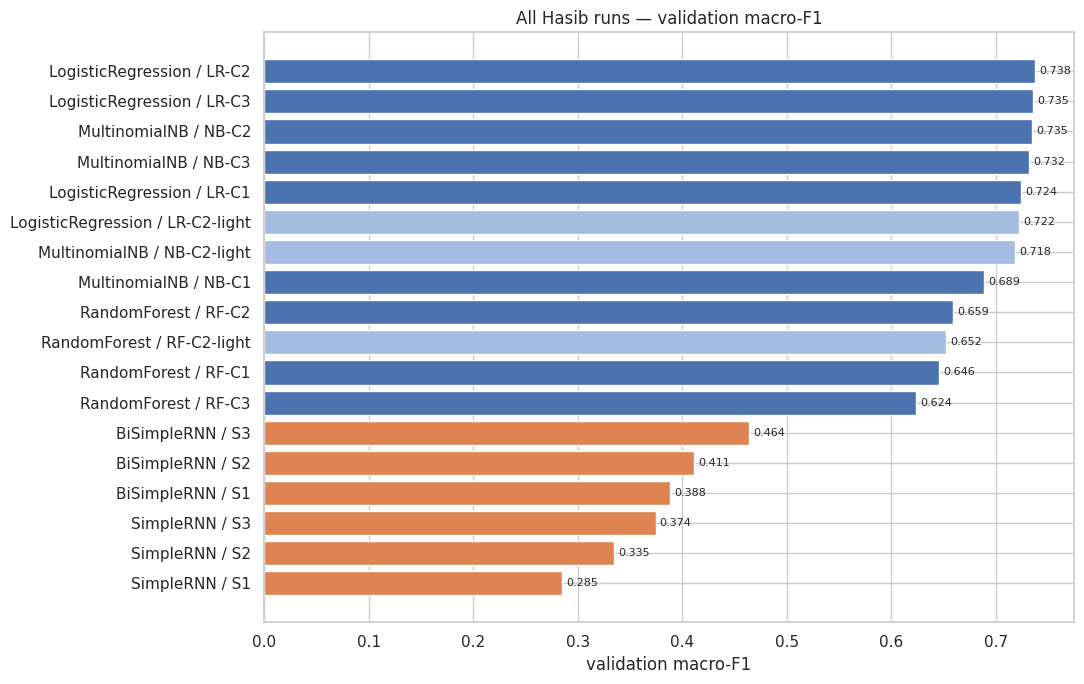

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
plot_df = runs_df.assign(run=runs_df.model + " / " + runs_df.config) \
                 .sort_values("val_macro_f1")
palette = {("classical", "required"): "#4c72b0",
           ("classical", "ablation"): "#a3bce0",
           ("recurrent", "required"): "#dd8452"}
colors = [palette.get((t, k), "#999999")
          for t, k in zip(plot_df.tier, plot_df.kind)]
ax.barh(plot_df.run, plot_df.val_macro_f1, color=colors)
ax.set_xlabel("validation macro-F1")
ax.set_title("All Hasib runs — validation macro-F1")
for y, v in zip(range(len(plot_df)), plot_df.val_macro_f1):
    ax.text(v + 0.004, y, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
save_fig(fig, "val_leaderboard_hasib.png")
plt.show()

## Test evaluation

Only the winning configuration of each model is evaluated on test, and only once.

`ev.evaluate_model` returns everything section 3.9 requires: accuracy, macro and
weighted F1, the full classification report, the row-normalised confusion matrix, and
the within-family against cross-family error split.

In [ ]:
test_results = {}
test_preds = {}


def evaluate_on_test(label, run_id, y_pred_or_probs):
    res = ev.evaluate_model(y_test, y_pred_or_probs, CLASS_NAMES, SUPERCLASS,
                            model_name=label, split="test", verbose=True)
    test_results[label] = res
    test_preds[label] = ev.to_labels(y_pred_or_probs)

    df = pd.read_csv(RUNS_CSV)
    hit = df.run_id == run_id
    assert hit.sum() == 1, f"expected one row for {run_id}, found {int(hit.sum())}"
    df.loc[hit, "test_accuracy"]    = round(res["accuracy"], 4)
    df.loc[hit, "test_macro_f1"]    = round(res["macro_f1"], 4)
    df.loc[hit, "test_weighted_f1"] = round(res["weighted_f1"], 4)
    df.to_csv(RUNS_CSV, index=False)
    return res


for name, b in best_classical.items():
    evaluate_on_test(f"{name} ({b['config']})", b["run_id"],
                     b["estimator"].predict(X_test_tfidf))
    print()

for arch, b in best_sequence.items():
    evaluate_on_test(f"{arch} ({b['config']})", b["run_id"],
                     b["model"].predict(X_test_seq, batch_size=256, verbose=0))
    print()

LogisticRegression (LR-C2)  [test]
  accuracy    : 0.6982
  macro-F1    : 0.6852
  weighted-F1 : 0.6960
  errors      : 2,192 (798 within-family = 36.4%, 1,394 cross-family = 63.6%)

MultinomialNB (NB-C2)  [test]
  accuracy    : 0.7038
  macro-F1    : 0.6843
  weighted-F1 : 0.6969
  errors      : 2,151 (802 within-family = 37.3%, 1,349 cross-family = 62.7%)

RandomForest (RF-C2)  [test]
  accuracy    : 0.6373
  macro-F1    : 0.6134
  weighted-F1 : 0.6271
  errors      : 2,634 (908 within-family = 34.5%, 1,726 cross-family = 65.5%)

SimpleRNN (S3)  [test]
  accuracy    : 0.3912
  macro-F1    : 0.3405
  weighted-F1 : 0.3522
  errors      : 4,421 (1,950 within-family = 44.1%, 2,471 cross-family = 55.9%)

BiSimpleRNN (S3)  [test]
  accuracy    : 0.4683
  macro-F1    : 0.4328
  weighted-F1 : 0.4440
  errors      : 3,861 (1,809 within-family = 46.9%, 2,052 cross-family = 53.1%)



### Classification reports

Printed in full. The brief requires a full classification report per model, and a cell
without visible output cannot be verified.

In [ ]:
for label, res in test_results.items():
    print("=" * 78)
    print(label)
    print("=" * 78)
    print(res["report_str"])

LogisticRegression (LR-C2)
                          precision    recall  f1-score   support

             alt.atheism     0.4770    0.4693    0.4731       309
           comp.graphics     0.6510    0.6885    0.6692       382
 comp.os.ms-windows.misc     0.6297    0.6148    0.6222       379
comp.sys.ibm.pc.hardware     0.6549    0.6276    0.6410       384
   comp.sys.mac.hardware     0.6950    0.7100    0.7024       369
          comp.windows.x     0.7796    0.7256    0.7517       390
            misc.forsale     0.7361    0.8064    0.7696       377
               rec.autos     0.7426    0.7548    0.7486       367
         rec.motorcycles     0.7600    0.7441    0.7520       383
      rec.sport.baseball     0.8415    0.8213    0.8313       375
        rec.sport.hockey     0.8835    0.8995    0.8914       388
               sci.crypt     0.8251    0.7507    0.7861       377
         sci.electronics     0.5674    0.5868    0.5770       380
                 sci.med     0.7836    0.7836   

### Confusion matrices

Row-normalised, so a bright off-diagonal cell means a class is losing a large share of
its own documents rather than simply being large.

saved /content/hasib_outputs/confusion_matrices_hasib.png
copied to /content/drive/MyDrive/cse440_project/figures/hasib/confusion_matrices_hasib.png


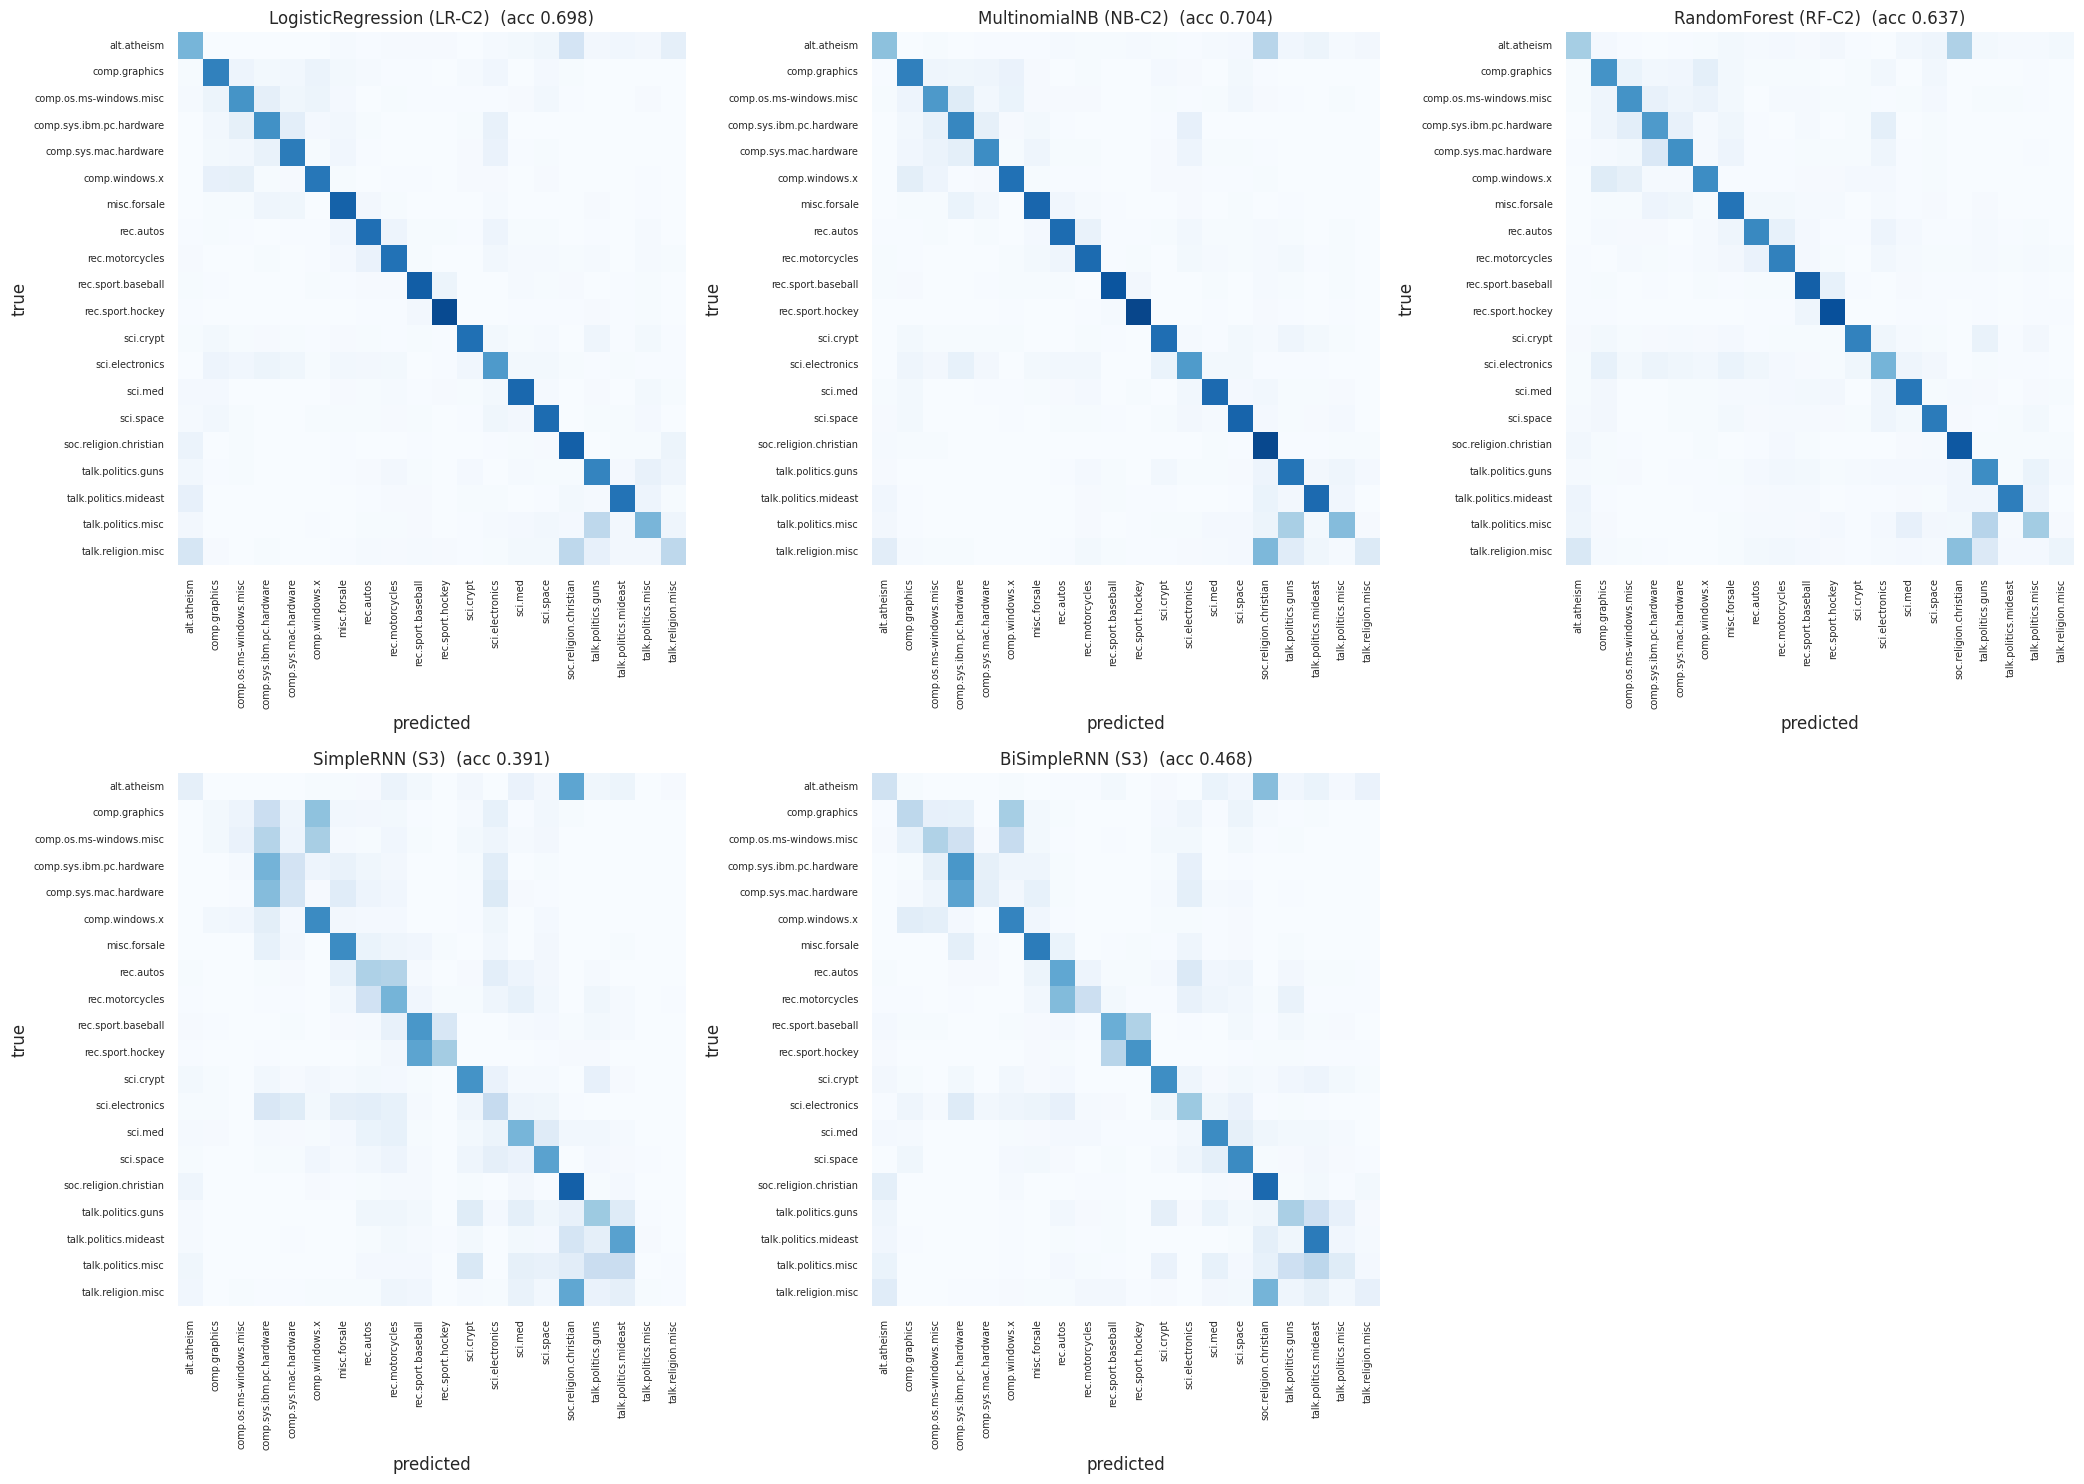

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(21, 15))

for ax, (label, res) in zip(axes.ravel(), test_results.items()):
    sns.heatmap(res["cm_norm"], ax=ax, cmap="Blues", vmin=0, vmax=1, cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{label}  (acc {res['accuracy']:.3f})")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)

for ax in axes.ravel()[len(test_results):]:
    ax.axis("off")

plt.tight_layout()
save_fig(fig, "confusion_matrices_hasib.png")
plt.show()

### Within-family versus cross-family errors

The 20 labels group into 7 families. Confusing two `comp.*` groups is a fine-grained
failure between similar topics. Confusing one with `talk.politics.guns` is a failure at
topic identification.

If wrong answers were spread randomly over the other 19 labels, about 15% would land in
the same family by chance. Anything well above that means the errors are semantic.

In [ ]:
rows = []
for label, res in test_results.items():
    f = res["family"]
    rows.append({
        "model": label,
        "errors": f["n_errors"],
        "within-family": f["within_family"],
        "cross-family": f["cross_family"],
        "within-family %": round(100 * f["within_share"], 1),
        "family accuracy": round(1 - f["cross_family"] / len(y_test), 4),
    })

family_df = pd.DataFrame(rows).sort_values("family accuracy", ascending=False)
print(family_df.to_string(index=False))

                     model  errors  within-family  cross-family  within-family %  family accuracy
     MultinomialNB (NB-C2)    2151            802          1349             37.3           0.8142
LogisticRegression (LR-C2)    2192            798          1394             36.4           0.8080
      RandomForest (RF-C2)    2634            908          1726             34.5           0.7623
          BiSimpleRNN (S3)    3861           1809          2052             46.9           0.7174
            SimpleRNN (S3)    4421           1950          2471             44.1           0.6597


In [ ]:
best_label = max(test_results, key=lambda n: test_results[n]["accuracy"])

conf = ev.top_confusions(y_test, test_preds[best_label], CLASS_NAMES, SUPERCLASS, k=12)
print(f"top confusions — {best_label}\n")
print(conf.to_string(index=False))
print(f"\nshare of these staying inside one family: {conf['same_family'].mean():.0%}")

top confusions — MultinomialNB (NB-C2)

                    true                predicted  count  pct_of_true_class  same_family
      talk.religion.misc   soc.religion.christian    111             0.4568        False
      talk.politics.misc       talk.politics.guns    103             0.3411         True
             alt.atheism   soc.religion.christian     91             0.2945        False
 comp.os.ms-windows.misc comp.sys.ibm.pc.hardware     45             0.1187         True
          comp.windows.x            comp.graphics     41             0.1051         True
   comp.sys.mac.hardware comp.sys.ibm.pc.hardware     35             0.0949         True
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware     34             0.0885         True
comp.sys.ibm.pc.hardware          sci.electronics     32             0.0833        False
         sci.electronics comp.sys.ibm.pc.hardware     30             0.0789        False
comp.sys.ibm.pc.hardware  comp.os.ms-windows.misc     30             0

## Export

The run log is checked against the shared 26-column schema before it is written. If the
columns do not match, the file will not concatenate with the other three and the merge
would fail silently.

Every row carries `dataset_checksum`, so the final 36-row table proves all four
contributors measured on the same data.

In [ ]:
for label, res in test_results.items():
    stem = "test_" + (label.replace(" ", "_").replace("(", "").replace(")", ""))
    local_json = LOCAL_OUT / f"{stem}.json"
    ev.save_result(res, LOCAL_OUT, stem)
    save_artifact(local_json, RESULT_DIR, DRIVE_RES_OK)

runs_df = pd.read_csv(RUNS_CSV)

assert list(runs_df.columns) == list(ev.RUN_COLUMNS), (
    "runs_hasib.csv does not match the shared schema — it will not concatenate")
assert runs_df.dataset_checksum.nunique() == 1, "rows disagree on dataset_checksum"
assert set(runs_df.tier) <= set(ev.TIERS), f"unexpected tier: {set(runs_df.tier)}"
assert set(runs_df.notes.str.split(" ").str[0]) <= set(ev.NOTE_KINDS), "bad notes token"

save_artifact(RUNS_CSV, RESULT_DIR, DRIVE_RES_OK)

print(f"\n{len(runs_df)} runs logged, {len(runs_df.columns)}-column schema v"
      f"{ev.SCORING_CONTRACT_VERSION}")
print(runs_df[["run_id", "tier", "model", "config", "embedding", "val_accuracy",
               "val_macro_f1", "test_accuracy", "test_macro_f1"]].to_string(index=False))

saved /content/hasib_outputs/test_LogisticRegression_LR-C2.json
copied to /content/drive/MyDrive/cse440_project/results/hasib/test_LogisticRegression_LR-C2.json
saved /content/hasib_outputs/test_MultinomialNB_NB-C2.json
copied to /content/drive/MyDrive/cse440_project/results/hasib/test_MultinomialNB_NB-C2.json
saved /content/hasib_outputs/test_RandomForest_RF-C2.json
copied to /content/drive/MyDrive/cse440_project/results/hasib/test_RandomForest_RF-C2.json
saved /content/hasib_outputs/test_SimpleRNN_S3.json
copied to /content/drive/MyDrive/cse440_project/results/hasib/test_SimpleRNN_S3.json
saved /content/hasib_outputs/test_BiSimpleRNN_S3.json
copied to /content/drive/MyDrive/cse440_project/results/hasib/test_BiSimpleRNN_S3.json
saved /content/hasib_outputs/runs_hasib.csv
copied to /content/drive/MyDrive/cse440_project/results/hasib/runs_hasib.csv

18 runs logged, 26-column schema v1.1
                        run_id      tier              model      config   embedding  val_accuracy  va

In [ ]:
summary = (runs_df.dropna(subset=["test_accuracy"])
                  [["model", "config", "embedding", "hyperparams",
                    "val_macro_f1", "test_accuracy", "test_macro_f1"]]
                  .sort_values("test_macro_f1", ascending=False))

print("FINAL — best configuration per model, test set\n")
print(summary.to_string(index=False))
print(f"\nbest  : {summary.iloc[0].model} ({summary.iloc[0].config})")
print(f"worst : {summary.iloc[-1].model} ({summary.iloc[-1].config})")

FINAL — best configuration per model, test set

             model config   embedding                                                                                               hyperparams  val_macro_f1  test_accuracy  test_macro_f1
LogisticRegression  LR-C2 tfidf_clean                                                                                                {"C": 5.0}        0.7377         0.6982         0.6852
     MultinomialNB  NB-C2 tfidf_clean                                                                                            {"alpha": 0.1}        0.7348         0.7038         0.6843
      RandomForest  RF-C2 tfidf_clean                                      {"max_features": "sqrt", "min_samples_leaf": 2, "n_estimators": 600}        0.6593         0.6373         0.6134
       BiSimpleRNN     S3    word2vec {"batch_size": 64, "dropout": 0.5, "embedding": "word2vec", "lr": 0.001, "trainable": true, "units": 128}        0.4640         0.4683         0.4328
         Sim

=== CONTRIB END ===